<a href="https://colab.research.google.com/github/aWolander/google-colab/blob/main/Federated%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
from __future__ import annotations
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt
import random
import numpy as np
try:
    device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # i get an error when i run this locally
except:
    device="cpu"

transform = Compose([
    ToTensor(),
    Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
]) # https://github.com/facebookresearch/dino/blob/7c446df5b9f45747937fb0d72314eb9f7b66930a/eval_image_retrieval.py#L106

CIFAR100 = datasets.CIFAR100(
  root="data",
  download=True,
  transform=transform
)

In [49]:

def main():
    K= 100
    N = 10
    CIFAR100 = datasets.CIFAR100(
      root="data",
      download=True,
      transform=ToTensor()
    )
    train_dataset, validate_dataset, test_dataset = torch.utils.data.random_split(CIFAR100, [0.7,0.15,0.15])
    client_datasets = split_data_iid(train_dataset, K)
    test_split(client_datasets)

def create_label_indexing(dataset):
    label_index = {i: [] for i in range(100)}
    for idx, (_, label) in enumerate(dataset):
        label_index[label].append(idx)
    return label_index

def split_data_non_iid(dataset, K, N_c = 100):
    index_split = [ [] for _ in range(K) ]
    label_index = create_label_indexing(dataset)
    split_availible_labels = {}
    lablels_exhausted = [False]*K

    # Randomly choose which labels each client has access to
    for i in range(K):
        split_availible_labels[i] = random.sample(range(100), N_c)

    # stops if no more datapoints are left to assign to any client
    while not all(lablels_exhausted):
        for client in range(K):

            if not split_availible_labels[client]:
                lablels_exhausted[client] = True

            for label in split_availible_labels[client]:
                # if no indices are left for a label, remove the label
                if not label_index[label]:
                    split_availible_labels[client].remove(label)
                    continue

                index_split[client].append(label_index[label].pop())

    for client_indices in index_split:
        random.shuffle(client_indices)

    return [Subset(dataset, indices) for indices in index_split]


def split(l: list, n: int) -> list[list]:
    '''splits a list into n parts'''
    split_list = []
    for i in range(0, n):
        split_list.append(l[i::n])
    return split_list

def split_data_iid(dataset, K):
    index_split = [[] for x in range(K)]
    label_index = create_label_indexing(dataset)

    for label in range(0,100):
        split_indices = split(label_index[label],K)
        for client in range(0, K):
            index_split[client] += split_indices[client]

    for client_indices in index_split:
        random.shuffle(client_indices)
    return [Subset(dataset, indices) for indices in index_split]

def test_split(client_datasets):
    bottom = np.zeros(100)
    for client_id, client_dataset in enumerate(client_datasets):
        occurrences = np.zeros(100)
        for datapoint in client_dataset:
            label = datapoint[1]
            occurrences[label] += 1
        #print(occurrences)
        print(f"Client {client_id}: No. of nonzero elements: {np.count_nonzero(occurrences)} | Avg., stdev. of nonzero elements: {occurrences[occurrences>0].mean()}, {occurrences[occurrences>0].std()}") # should be N_c non-zero elements!
        plt.bar(range(100), occurrences, bottom=bottom, label=client_id)
        plt.xlabel("Class label")
        plt.ylabel("Number of samples")
        bottom += occurrences

    plt.show()

#main()

# def test_split_index(dataset):
#     K= 2
#     N = 5
#     client_data_split = split_data_non_iid(dataset, K, N)
#     for client_data in client_data_split:
#         occurences = {}
#         for index in client_data:
#             occurences[dataset[index][1]] = occurences.setdefault(dataset[index][1], 0) + 1
#         print(occurences)
#         plt.hist(occurences, stacked=True, bins=100)
#     plt.show()

In [59]:
class FL_client(DinoFullModel):
  '''
  Basically just the single model, but with addition and scaling functionality.
  To facilitate FedAvg more easily.
  '''
  def __init__(self):
    super().__init__()

  def __add__(self, other: FL_client) -> FL_client:
    assert isinstance(other, FL_client)
    temp_weights = []
    temp_biases = []
    for (name, self_param), (_,other_param) in zip(self.named_parameters(), other.named_parameters()):
      self_param.to(device)
      other_param.to(device)
      if 'weight' in name:
        temp_weights.append(self_param + other_param)
      elif 'bias' in name:
        temp_biases.append(self_param + other_param)
    temp_client = copy.deepcopy(self) # pointers??
    with torch.no_grad():
      i = 0
      for name, param in temp_client.named_parameters():
        if 'weight' in name:
          param.copy_(temp_weights[i])
          i += 1

      j = 0
      for name, param in temp_client.named_parameters():
        if 'bias' in name:
          param.copy_(temp_biases[j])
          j += 1
    # order?
    return temp_client

  def __mul__(self, multiplier: float|int) -> FL_client:
    assert isinstance(multiplier, float|int)
    temp_weights = []
    temp_biases = []
    for (name, self_param) in self.named_parameters():
      self_param.to(device)
      if 'weight' in name:
        temp_weights.append(self_param * multiplier)
      elif 'bias' in name:
        temp_biases.append(self_param * multiplier)

    temp_client = copy.deepcopy(self)
    #order?
    with torch.no_grad():
      i = 0
      for name, param in temp_client.named_parameters():
        if 'weight' in name:
          param.copy_(temp_weights[i])
          i += 1

      j = 0
      for name, param in temp_client.named_parameters():
        if 'bias' in name:
          param.copy_(temp_biases[j])
          j += 1
    return temp_client

  def __rmul__(self, multiplier: float|int) -> FL_client:
    return self.__mul__(multiplier)

  def __sub__(self, other: FL_client) -> FL_client:
    assert isinstance(other, FL_client)
    return self + (-other)

class FL_server():
  def __init__(self, K):
    self.model = DinoFullModel().to(device)

    self.K = K
    self.training_rounds = 10

    self.loss_fn = nn.CrossEntropyLoss()
    self.clients = []
    for i in range(self.K):
      self.clients.append(FL_client()) # pointers?


  def forward(self, x):
    return self.model.forward(x)


  def FedAvg(self, dataloaders_list, validate_dataloader, C):
    for round in range(self.training_rounds):
      m = max(C*self.K, 1)
      rand_set_clients = random.sample(range(self.K), m)
      client_model_sum = None
      m_t = 0
      for client_id in rand_set_clients:
        temp_client = self.clients[client_id]
        temp_loader = dataloaders_list[client_id]

        print(f"----------- TRAIN LOOP FOR CLIENT {client_id}. -----------")
        temp_client.train_model(temp_loader)
        n_k = len(temp_loader.dataset)
        m_t += n_k
        # Easier than instantiating an empty model
        if client_model_sum is None:
          client_model_sum = n_k*temp_client
        else:
          client_model_sum = client_model_sum + n_k*temp_client

      client_model_sum = (1/m_t) * client_model_sum
      self.model = client_model_sum.model
      print(f"----------- VALIDATION FOR SERVER. -----------")
      self.test_model(validate_dataloader)


  def test_model(self, dataloader):
    #print(f"Validation Loss: {avg_loss:.4f}, Correct: {total_correct} out of {len(dataloader)}, Accuracy: {accuracy:.2%}")
    return self.model.test_model(dataloader)

In [73]:
class DinoFullModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16').to(device)

    # Freeze the backbone if desired
        # for param in self.model.parameters():
        #     param.requires_grad = False
    self.model.head = nn.Sequential(
        nn.Linear(self.model.embed_dim, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(128, 100)
    ).to(device)

    self.learning_rate = 1e-3
    self.epochs = 20

    self.loss_fn = nn.CrossEntropyLoss()
    self.optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)

    self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
      self.optimizer, T_max=self.epochs
    )
    self.training_loss_history = []
    self.training_accuracy_history = []
    self.validate_accuracy_history = []
    self.validate_loss_history = []

  def forward(self, x):
    return self.model.head(self.model(x))

  def train_model(self, dataloader, validate_dataloader=None):
    dataset_size = len(dataloader.dataset)
    batch_size = dataloader.batch_size
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    self.train()

    for epoch in range(self.epochs):
      print(f"-------------------------------\nEpoch {epoch+1}\n-------------------------------")

      current = 0
      running_loss = 0
      total_loss = 0
      total_correct = 0
      for X, y in dataloader:
        # Compute prediction and loss
        X, y = X.to(device), y.to(device)

        prediction = self.forward(X).to(device)
        loss = self.loss_fn(prediction, y)
        batch_correct = torch.sum(prediction.argmax(dim=1) == y).item()
        total_correct += batch_correct

        total_loss += loss.item()*batch_size
        # Backpropagation
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()
        current += batch_size
        if current % 5000 == 0:
          print(f"loss: {loss:>7f}  [{current:>5d}/{dataset_size:>5d}]")
          loss = loss.item()


      if validate_dataloader is not None:
        self.training_loss_history.append(total_loss / dataset_size)
        self.training_accuracy_history.append(total_correct / dataset_size)

        validate_loss, validate_accuracy = self.test_model(validate_dataloader)

        self.validate_loss_history.append(validate_loss)
        self.validate_accuracy_history.append(validate_accuracy)

      self.scheduler.step()

  def test_model(self, dataloader):
    self.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    dataset_size = len(dataloader.dataset)
    batch_size = dataloader.batch_size


    with torch.no_grad():
      for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # Compute prediction and loss
        X, y = X.to(device), y.to(device)

        prediction = self.forward(X).to(device)
        loss = self.loss_fn(prediction, y)
        batch_correct = torch.sum(prediction.argmax(dim=1) == y).item()
        total_correct += batch_correct

        total_loss += loss.item()*batch_size


    avg_loss = total_loss / dataset_size
    accuracy = total_correct / dataset_size

    #print(f"Validation Loss: {avg_loss:.4f}, Correct: {total_correct} out of {len(dataloader)}, Accuracy: {accuracy:.2%}")

    return avg_loss, accuracy

  def plot_performance(self):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Loss
    axs[0].plot(range(self.epochs), self.training_loss_history, label='Training Loss', color='blue')  # Move tensor to CPU before converting to NumPy
    axs[0].plot(range(self.epochs), self.validate_loss_history, label='Validation Loss', color='orange')  # Move tensor to CPU before converting to NumPy
    #axs[0].plot(range(self.epochs), validate_loss_history, label='Validation Loss', color='orange')

    axs[0].set_title('Loss over Epochs')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # Plot Accuracy
    axs[1].plot(range(self.epochs), self.training_accuracy_history, label='Training Accuracy', color='blue')  # Move tensor to CPU before converting to NumPy
    axs[1].plot(range(self.epochs), self.validate_accuracy_history, label='Validation Accuracy', color='orange')  # Move tensor to CPU before converting to NumPy
    #axs[1].plot(range(self.epochs), validate_accuracy_history, label='Validation Accuracy', color='orange')
    axs[1].set_title('Accuracy over Epochs')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


-------------------------------
Epoch 1
-------------------------------
loss: 4.651278  [ 5000/40000]
loss: 4.608053  [10000/40000]
loss: 4.578539  [15000/40000]
loss: 4.567330  [20000/40000]
loss: 4.618789  [25000/40000]
loss: 4.591909  [30000/40000]
loss: 4.559279  [35000/40000]
loss: 4.602777  [40000/40000]
-------------------------------
Epoch 2
-------------------------------
loss: 4.549370  [ 5000/40000]
loss: 4.441598  [10000/40000]
loss: 4.251479  [15000/40000]
loss: 4.216341  [20000/40000]
loss: 4.055691  [25000/40000]
loss: 3.889887  [30000/40000]
loss: 3.839415  [35000/40000]
loss: 3.604715  [40000/40000]
-------------------------------
Epoch 3
-------------------------------
loss: 3.513548  [ 5000/40000]
loss: 3.298671  [10000/40000]
loss: 3.181088  [15000/40000]
loss: 2.971097  [20000/40000]
loss: 2.908141  [25000/40000]
loss: 2.693563  [30000/40000]
loss: 2.507080  [35000/40000]
loss: 2.602371  [40000/40000]
-------------------------------
Epoch 4
------------------------

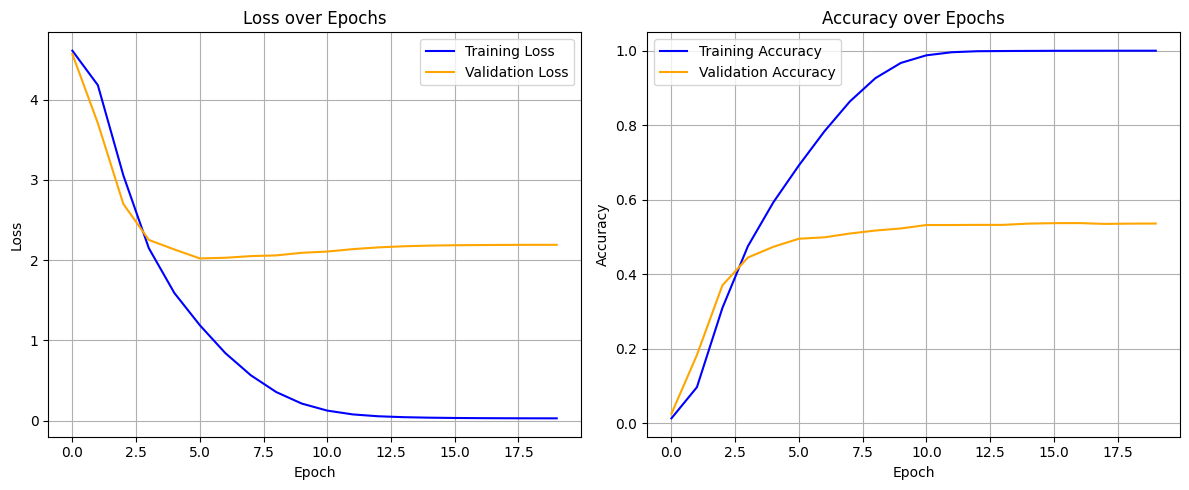

Done!


In [80]:

'''
TODO:
Batch normalization, probably. I think I read somewhere that the facebook model needs this
Version control and checkpointing.
  - added version control, checkpoitning left //Gustav
Testing and hyperparameter tuning. also model head architecture
gradient mask TaLoS thing. Also expanding this to FL.
Plot accuracy and loss method in DinoFullModel
  - added // Gustav
'''
train_dataset, validate_dataset, test_dataset = torch.utils.data.random_split(CIFAR100, [0.8,0.1,0.1])

def FL_test():
  K=5
  FL = FL_server(K)
  split_dataset = split_data_iid(train_dataset, K)

  train_dataloader = [DataLoader(subset, batch_size=100) for subset in split_dataset]

  test_dataloader = DataLoader(test_dataset, batch_size=100)
  validate_dataloader = DataLoader(validate_dataset, batch_size=100)

  FL.FedAvg(train_dataloader, validate_dataloader, 1)
  FL.test_model(test_dataloader)

def single_test():

  train_dataloader = DataLoader(train_dataset, batch_size=100)
  test_dataloader = DataLoader(test_dataset, batch_size=100)
  validate_dataloader = DataLoader(validate_dataset, batch_size=100)

  model = DinoFullModel().to(device)
  #for param in model.parameters():
  #    print(param.shape)

  model.train_model(train_dataloader, validate_dataloader=validate_dataloader)
  model.plot_performance()
  print("Done!")

single_test()
